In [1]:
!pip install -q transformers

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    WavLMModel,
    Wav2Vec2FeatureExtractor
)

print("Imports successful")

Imports successful


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DATASET_PATH = "/content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge"

TRAIN_AUDIO_PATH = os.path.join(
    DATASET_PATH,
    "train"
)

TEST_AUDIO_PATH = os.path.join(
    DATASET_PATH,
    "test"
)

PROCESSED_PATH = os.path.join(
    DATASET_PATH,
    "processed_features"
)

print("Dataset path:", DATASET_PATH)
print("Processed path:", PROCESSED_PATH)

Dataset path: /content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge
Processed path: /content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge/processed_features


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [6]:
train_df = pd.read_csv(
    os.path.join(DATASET_PATH, "Train.csv")
)

train_df["audio_path"] = train_df["File_name"].apply(
    lambda x: os.path.join(TRAIN_AUDIO_PATH, x)
)

print("Train shape:", train_df.shape)
train_df.head()

Train shape: (89, 8)


,Participant,File_name,Label,Score,Gender,Age,Remark,audio_path
0,S026,S026.mp3,2,24,Female,23,NaN,/content/drive/MyDrive/bio-cas-2024-depression...
1,S055,S055.mp3,3,37,Female,18,NaN,/content/drive/MyDrive/bio-cas-2024-depression...
2,S029,S029.mp3,0,3,Female,33,NaN,/content/drive/MyDrive/bio-cas-2024-depression...
3,S089,S089.mp3,0,0,Male,46,NaN,/content/drive/MyDrive/bio-cas-2024-depression...
4,S005,S005.mp3,2,26,Female,16,NaN,/content/drive/MyDrive/bio-cas-2024-depression...


In [7]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_indices, val_indices = next(
    skf.split(
        train_df,
        train_df["Label"]
    )
)

train_participants = train_df.iloc[
    train_indices
].copy()

val_participants = train_df.iloc[
    val_indices
].copy()

print(
    "Training participants:",
    len(train_participants)
)

print(
    "Validation participants:",
    len(val_participants)
)

print("\nTraining label distribution:")
print(train_participants["Label"].value_counts().sort_index())

print("\nValidation label distribution:")
print(val_participants["Label"].value_counts().sort_index())

Training participants: 71
Validation participants: 18

Training label distribution:
Label
0    33
1     6
2    20
3    12
Name: count, dtype: int64

Validation label distribution:
Label
0    8
1    1
2    6
3    3
Name: count, dtype: int64


In [8]:
MODEL_NAME = "microsoft/wavlm-base-plus"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_NAME
)

wavlm = WavLMModel.from_pretrained(
    MODEL_NAME
)

wavlm = wavlm.to(device)

print("WavLM loaded successfully")

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

WavLM loaded successfully


In [9]:
for param in wavlm.parameters():
    param.requires_grad = False

wavlm.eval()

print("WavLM parameters frozen")

WavLM parameters frozen


In [10]:
sample_path = train_participants.iloc[0]["audio_path"]

audio, sr = librosa.load(
    sample_path,
    sr=16000,
    mono=True
)

segment_samples = 5 * 16000

segment = audio[:segment_samples]

inputs = feature_extractor(
    segment,
    sampling_rate=16000,
    return_tensors="pt"
)

input_values = inputs.input_values.to(device)

print("Input shape:", input_values.shape)

with torch.no_grad():

    outputs = wavlm(
        input_values
    )

hidden_states = outputs.last_hidden_state

print(
    "WavLM hidden-state shape:",
    hidden_states.shape
)

embedding = hidden_states.mean(
    dim=1
)

print(
    "Mean pooled embedding shape:",
    embedding.shape
)

/tmp/ipykernel_697/2202557254.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Input shape: torch.Size([1, 80000])
WavLM hidden-state shape: torch.Size([1, 249, 768])
Mean pooled embedding shape: torch.Size([1, 768])


In [11]:
def extract_wavlm_embeddings(
    dataframe,
    model,
    feature_extractor,
    device,
    sr=16000,
    segment_duration=5
):

    model.eval()

    segment_samples = sr * segment_duration

    all_embeddings = []
    all_labels = []
    all_participants = []

    for _, row in dataframe.iterrows():

        audio_path = row["audio_path"]
        label = int(row["Label"])
        participant = row["Participant"]

        audio, _ = librosa.load(
            audio_path,
            sr=sr,
            mono=True
        )

        num_segments = (
            len(audio) // segment_samples
        )

        for segment_idx in range(num_segments):

            start = (
                segment_idx *
                segment_samples
            )

            end = (
                start +
                segment_samples
            )

            segment = audio[start:end]

            inputs = feature_extractor(
                segment,
                sampling_rate=sr,
                return_tensors="pt"
            )

            input_values = inputs.input_values.to(
                device
            )

            with torch.no_grad():

                outputs = model(
                    input_values
                )

                hidden_states = (
                    outputs.last_hidden_state
                )

                embedding = hidden_states.mean(
                    dim=1
                )

            all_embeddings.append(
                embedding.squeeze(0)
                .cpu()
                .numpy()
            )

            all_labels.append(label)

            all_participants.append(
                participant
            )

    return (
        np.array(all_embeddings),
        np.array(all_labels),
        np.array(all_participants)
    )

In [12]:
start_time = time.time()

X_wavlm_train, y_wavlm_train, participants_wavlm_train = (
    extract_wavlm_embeddings(
        train_participants,
        wavlm,
        feature_extractor,
        device
    )
)

elapsed = time.time() - start_time

print(
    "Training embeddings shape:",
    X_wavlm_train.shape
)

print(
    "Training labels shape:",
    y_wavlm_train.shape
)

print(
    "Training participants shape:",
    participants_wavlm_train.shape
)

print(
    f"Extraction time: {elapsed/60:.2f} minutes"
)

/tmp/ipykernel_697/4209746636.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_697/4209746636.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_697/4209746636.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.cor

Training embeddings shape: (5307, 768)
Training labels shape: (5307,)
Training participants shape: (5307,)
Extraction time: 6.37 minutes


In [13]:
start_time = time.time()

X_wavlm_val, y_wavlm_val, participants_wavlm_val = (
    extract_wavlm_embeddings(
        val_participants,
        wavlm,
        feature_extractor,
        device
    )
)

elapsed = time.time() - start_time

print(
    "Validation embeddings shape:",
    X_wavlm_val.shape
)

print(
    "Validation labels shape:",
    y_wavlm_val.shape
)

print(
    "Validation participants shape:",
    participants_wavlm_val.shape
)

print(
    f"Extraction time: {elapsed/60:.2f} minutes"
)

/tmp/ipykernel_697/4209746636.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_697/4209746636.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_697/4209746636.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.cor

Validation embeddings shape: (1203, 768)
Validation labels shape: (1203,)
Validation participants shape: (1203,)
Extraction time: 1.57 minutes


In [14]:
np.save(
    os.path.join(
        PROCESSED_PATH,
        "X_wavlm_train.npy"
    ),
    X_wavlm_train
)

np.save(
    os.path.join(
        PROCESSED_PATH,
        "y_wavlm_train.npy"
    ),
    y_wavlm_train
)

np.save(
    os.path.join(
        PROCESSED_PATH,
        "participants_wavlm_train.npy"
    ),
    participants_wavlm_train
)

np.save(
    os.path.join(
        PROCESSED_PATH,
        "X_wavlm_val.npy"
    ),
    X_wavlm_val
)

np.save(
    os.path.join(
        PROCESSED_PATH,
        "y_wavlm_val.npy"
    ),
    y_wavlm_val
)

np.save(
    os.path.join(
        PROCESSED_PATH,
        "participants_wavlm_val.npy"
    ),
    participants_wavlm_val
)

print("All WavLM embeddings saved.")

All WavLM embeddings saved.


In [15]:
class WavLMClassifier(nn.Module):

    def __init__(
        self,
        input_dim=768,
        num_classes=4
    ):

        super().__init__()

        self.classifier = nn.Sequential(

            nn.Linear(
                input_dim,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        return self.classifier(x)

In [16]:
class EmbeddingDataset(Dataset):

    def __init__(
        self,
        X,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.y)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )

In [17]:
train_embedding_dataset = EmbeddingDataset(
    X_wavlm_train,
    y_wavlm_train
)

val_embedding_dataset = EmbeddingDataset(
    X_wavlm_val,
    y_wavlm_val
)

train_embedding_loader = DataLoader(
    train_embedding_dataset,
    batch_size=32,
    shuffle=True
)

val_embedding_loader = DataLoader(
    val_embedding_dataset,
    batch_size=32,
    shuffle=False
)

In [18]:
class_counts = np.bincount(
    y_wavlm_train,
    minlength=4
)

class_weights = (
    len(y_wavlm_train) /
    (
        4 *
        class_counts
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print(
    "Class counts:",
    class_counts
)

print(
    "Class weights:",
    class_weights
)

Class counts: [1160  444 2364 1339]
Class weights: tensor([1.1437, 2.9882, 0.5612, 0.9909], device='cuda:0')


In [19]:
frozen_model = WavLMClassifier(
    input_dim=768,
    num_classes=4
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    frozen_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print("Frozen WavLM classifier ready")

Frozen WavLM classifier ready


In [20]:
def evaluate_embedding_model(
    model,
    X,
    y,
    participants,
    device
):

    model.eval()

    participant_probs = {}
    participant_labels = {}

    dataset = EmbeddingDataset(
        X,
        y
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    with torch.no_grad():

        start = 0

        for batch_X, batch_y in loader:

            batch_X = batch_X.to(device)

            outputs = model(batch_X)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            probs = probs.cpu().numpy()

            batch_size = len(batch_y)

            batch_participants = participants[
                start:start + batch_size
            ]

            batch_labels = batch_y.numpy()

            for prob, label, participant in zip(
                probs,
                batch_labels,
                batch_participants
            ):

                if participant not in participant_probs:

                    participant_probs[
                        participant
                    ] = []

                participant_probs[
                    participant
                ].append(prob)

                participant_labels[
                    participant
                ] = int(label)

            start += batch_size

    y_true = []
    y_pred = []

    for participant in participant_probs:

        avg_prob = np.mean(
            participant_probs[participant],
            axis=0
        )

        prediction = np.argmax(
            avg_prob
        )

        y_true.append(
            participant_labels[participant]
        )

        y_pred.append(
            prediction
        )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return (
        macro_f1,
        balanced_acc,
        accuracy,
        y_true,
        y_pred
    )

In [21]:
NUM_EPOCHS = 30
PATIENCE = 5

best_f1 = -1
patience_counter = 0

history = {
    "epoch": [],
    "train_loss": [],
    "val_macro_f1": [],
    "val_balanced_accuracy": []
}

BEST_FROZEN_PATH = os.path.join(
    PROCESSED_PATH,
    "wavlm_best_classifier.pth"
)

for epoch in range(NUM_EPOCHS):

    frozen_model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_embedding_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = frozen_model(
            X_batch
        )

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            X_batch.size(0)
        )

    train_loss = (
        running_loss /
        len(train_embedding_dataset)
    )

    (
        val_f1,
        val_balanced_acc,
        val_accuracy,
        _,
        _
    ) = evaluate_embedding_model(
        frozen_model,
        X_wavlm_val,
        y_wavlm_val,
        participants_wavlm_val,
        device
    )

    history["epoch"].append(
        epoch + 1
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_macro_f1"].append(
        val_f1
    )

    history["val_balanced_accuracy"].append(
        val_balanced_acc
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Macro F1: {val_f1:.4f} | "
        f"Balanced Acc: {val_balanced_acc:.4f}"
    )

    if val_f1 > best_f1:

        best_f1 = val_f1
        patience_counter = 0

        torch.save(
            frozen_model.state_dict(),
            BEST_FROZEN_PATH
        )

        print("  Best model saved.")

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping.")

            break

Epoch 01 | Loss: 1.2826 | Macro F1: 0.2059 | Balanced Acc: 0.2500
  Best model saved.
Epoch 02 | Loss: 1.1350 | Macro F1: 0.2188 | Balanced Acc: 0.2500
  Best model saved.
Epoch 03 | Loss: 1.0652 | Macro F1: 0.2958 | Balanced Acc: 0.2917
  Best model saved.
Epoch 04 | Loss: 1.0236 | Macro F1: 0.4549 | Balanced Acc: 0.5000
  Best model saved.
Epoch 05 | Loss: 0.9804 | Macro F1: 0.5104 | Balanced Acc: 0.5417
  Best model saved.
Epoch 06 | Loss: 0.9295 | Macro F1: 0.2857 | Balanced Acc: 0.2976
Epoch 07 | Loss: 0.8854 | Macro F1: 0.2812 | Balanced Acc: 0.3333
Epoch 08 | Loss: 0.8488 | Macro F1: 0.4549 | Balanced Acc: 0.5000
Epoch 09 | Loss: 0.8105 | Macro F1: 0.3902 | Balanced Acc: 0.4583
Epoch 10 | Loss: 0.7763 | Macro F1: 0.4549 | Balanced Acc: 0.5000
Early stopping.


In [22]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(
        PROCESSED_PATH,
        "wavlm_training_history.csv"
    ),
    index=False
)

history_df.head()

,epoch,train_loss,val_macro_f1,val_balanced_accuracy
0,1,1.282597,0.205882,0.250000
1,2,1.135003,0.218750,0.250000
2,3,1.065200,0.295833,0.291667
3,4,1.023614,0.454861,0.500000
4,5,0.980383,0.510417,0.541667


In [23]:
frozen_model.load_state_dict(
    torch.load(
        BEST_FROZEN_PATH,
        map_location=device
    )
)

(
    frozen_f1,
    frozen_balanced_acc,
    frozen_accuracy,
    y_true_frozen,
    y_pred_frozen
) = evaluate_embedding_model(
    frozen_model,
    X_wavlm_val,
    y_wavlm_val,
    participants_wavlm_val,
    device
)

print(
    f"Frozen WavLM Macro F1: {frozen_f1:.4f}"
)

print(
    f"Frozen WavLM Balanced Accuracy: {frozen_balanced_acc:.4f}"
)

print(
    f"Frozen WavLM Accuracy: {frozen_accuracy:.4f}"
)

Frozen WavLM Macro F1: 0.5104
Frozen WavLM Balanced Accuracy: 0.5417
Frozen WavLM Accuracy: 0.7059


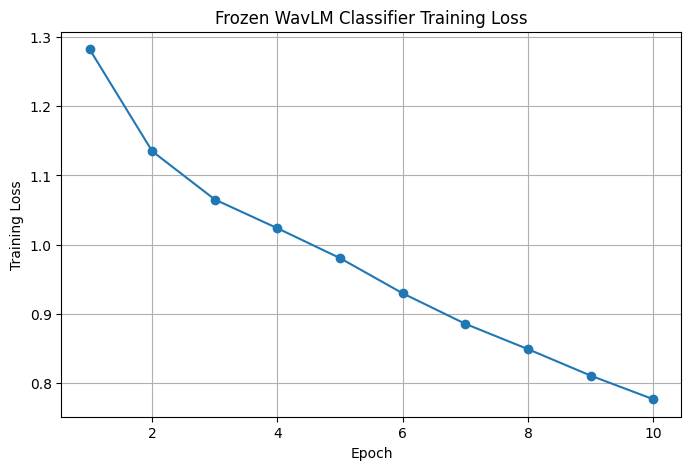

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Frozen WavLM Classifier Training Loss")

plt.grid(True)

plt.show()

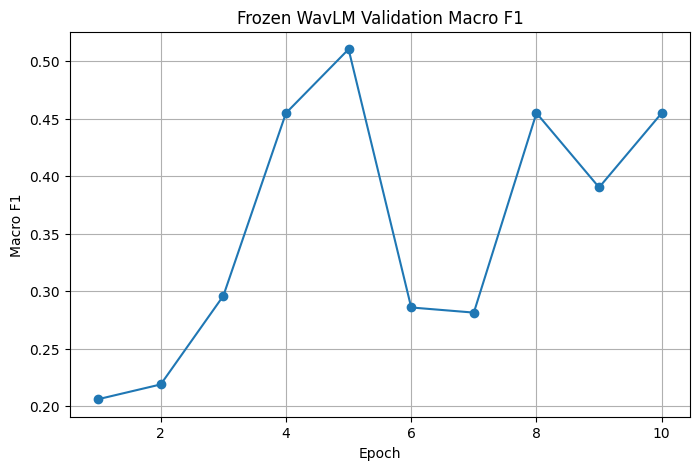

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Frozen WavLM Validation Macro F1")

plt.grid(True)

plt.show()

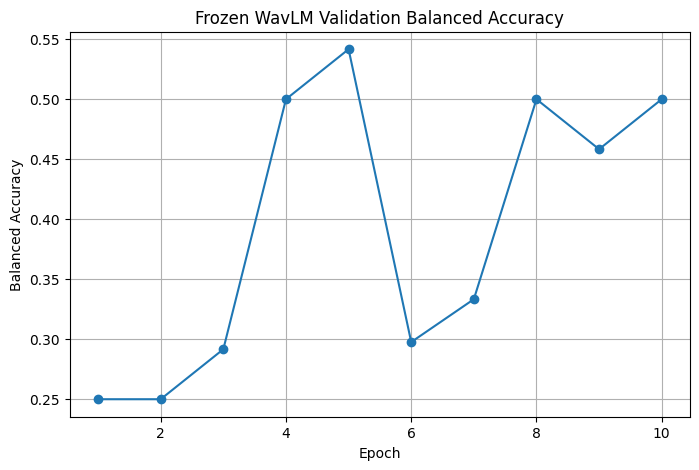

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_balanced_accuracy"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Frozen WavLM Validation Balanced Accuracy")

plt.grid(True)

plt.show()

In [27]:
print(
    classification_report(
        y_true_frozen,
        y_pred_frozen,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       0.00      0.00      0.00         1
           2       1.00      0.50      0.67         6
           3       0.40      0.67      0.50         3

    accuracy                           0.71        17
   macro avg       0.54      0.54      0.51        17
weighted avg       0.74      0.71      0.68        17



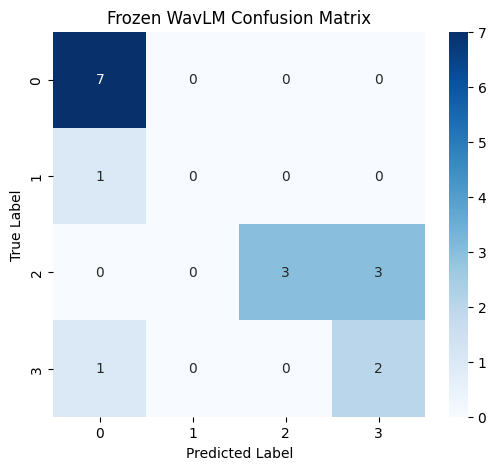

In [28]:
cm_frozen = confusion_matrix(
    y_true_frozen,
    y_pred_frozen,
    labels=[0, 1, 2, 3]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_frozen,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3],
    yticklabels=[0, 1, 2, 3]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Frozen WavLM Confusion Matrix")

plt.show()

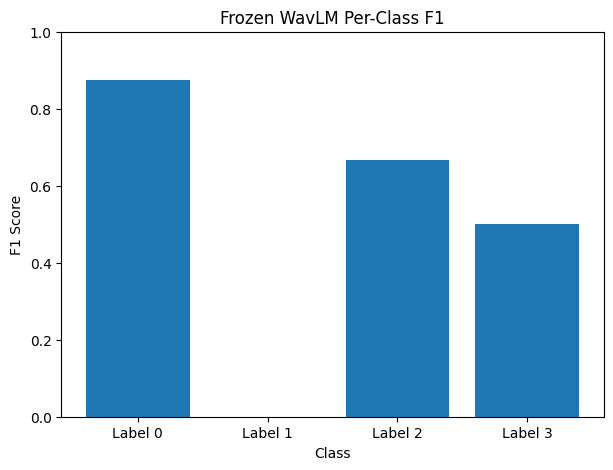

In [29]:
report_frozen = classification_report(
    y_true_frozen,
    y_pred_frozen,
    labels=[0, 1, 2, 3],
    output_dict=True,
    zero_division=0
)

per_class_f1_frozen = [
    report_frozen[str(i)]["f1-score"]
    for i in range(4)
]

plt.figure(figsize=(7, 5))

plt.bar(
    ["Label 0", "Label 1", "Label 2", "Label 3"],
    per_class_f1_frozen
)

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Frozen WavLM Per-Class F1")

plt.ylim(0, 1)

plt.show()

In [30]:
X_wavlm_train = np.load(
    os.path.join(PROCESSED_PATH, "X_wavlm_train.npy")
)

y_wavlm_train = np.load(
    os.path.join(PROCESSED_PATH, "y_wavlm_train.npy")
)

participants_wavlm_train = np.load(
    os.path.join(PROCESSED_PATH, "participants_wavlm_train.npy")
)

X_wavlm_val = np.load(
    os.path.join(PROCESSED_PATH, "X_wavlm_val.npy")
)

y_wavlm_val = np.load(
    os.path.join(PROCESSED_PATH, "y_wavlm_val.npy")
)

participants_wavlm_val = np.load(
    os.path.join(PROCESSED_PATH, "participants_wavlm_val.npy")
)

print("Train:", X_wavlm_train.shape)
print("Validation:", X_wavlm_val.shape)

Train: (5307, 768)
Validation: (1203, 768)


In [31]:
MODEL_NAME = "microsoft/wavlm-base-plus"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_NAME
)

wavlm_base = WavLMModel.from_pretrained(
    MODEL_NAME
).to(device)

print("WavLM loaded")

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

WavLM loaded


In [32]:
class WavLMFineTuner(nn.Module):

    def __init__(self, wavlm_model, num_classes=4):
        super().__init__()

        self.wavlm = wavlm_model

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, input_values):

        outputs = self.wavlm(input_values)

        hidden_states = outputs.last_hidden_state

        embedding = hidden_states.mean(dim=1)

        return self.classifier(embedding)

In [33]:
fine_tune_model = WavLMFineTuner(
    wavlm_base,
    num_classes=4
).to(device)

print("Fine-tuning model ready")

Fine-tuning model ready


In [34]:
for param in fine_tune_model.wavlm.parameters():
    param.requires_grad = False

for layer in fine_tune_model.wavlm.encoder.layers[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

for param in fine_tune_model.classifier.parameters():
    param.requires_grad = True

total_params = sum(
    p.numel()
    for p in fine_tune_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in fine_tune_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print(
    "Trainable %:",
    f"{100 * trainable_params / total_params:.2f}%"
)

Total parameters: 94612212
Trainable parameters: 14407084
Trainable %: 15.23%


In [35]:
class FastFineTuneSpeechDataset(Dataset):

    def __init__(
        self,
        dataframe,
        sr=16000,
        segment_duration=5
    ):

        self.sr = sr
        self.segment_samples = sr * segment_duration
        self.segments = []

        for _, row in dataframe.iterrows():

            audio, _ = librosa.load(
                row["audio_path"],
                sr=sr,
                mono=True
            )

            num_segments = (
                len(audio) // self.segment_samples
            )

            for segment_idx in range(num_segments):

                start = segment_idx * self.segment_samples
                end = start + self.segment_samples

                segment = audio[start:end].astype(
                    np.float32
                )

                self.segments.append({
                    "audio": segment,
                    "label": int(row["Label"]),
                    "participant": row["Participant"]
                })

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, index):

        item = self.segments[index]

        return (
            item["audio"],
            item["label"],
            item["participant"]
        )

In [36]:
fine_tune_train_dataset = FastFineTuneSpeechDataset(
    train_participants
)

fine_tune_val_dataset = FastFineTuneSpeechDataset(
    val_participants
)

print("Train segments:", len(fine_tune_train_dataset))
print("Validation segments:", len(fine_tune_val_dataset))

/tmp/ipykernel_697/4048358213.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_697/4048358213.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_697/4048358213.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.cor

Train segments: 5307
Validation segments: 1203


In [37]:
def wavlm_collate_fn(batch):

    audio_segments = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    participants = [item[2] for item in batch]

    inputs = feature_extractor(
        audio_segments,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    return (
        inputs.input_values,
        torch.tensor(labels, dtype=torch.long),
        participants
    )

In [38]:
fine_tune_train_loader = DataLoader(
    fine_tune_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=wavlm_collate_fn
)

fine_tune_val_loader = DataLoader(
    fine_tune_val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=wavlm_collate_fn
)

print("DataLoaders ready")

DataLoaders ready


In [39]:
def evaluate_finetuned_wavlm(
    model,
    loader,
    device
):

    model.eval()

    participant_probs = {}
    participant_labels = {}

    with torch.no_grad():

        for input_values, labels, participants in loader:

            input_values = input_values.to(device)

            outputs = model(input_values)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            probs = probs.cpu().numpy()
            labels = labels.numpy()

            for prob, label, participant in zip(
                probs,
                labels,
                participants
            ):

                if participant not in participant_probs:
                    participant_probs[participant] = []

                participant_probs[participant].append(prob)
                participant_labels[participant] = int(label)

    y_true = []
    y_pred = []

    for participant in participant_probs:

        avg_prob = np.mean(
            participant_probs[participant],
            axis=0
        )

        prediction = np.argmax(avg_prob)

        y_true.append(
            participant_labels[participant]
        )

        y_pred.append(prediction)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return (
        macro_f1,
        balanced_acc,
        accuracy,
        y_true,
        y_pred
    )

In [40]:
participant_class_counts = np.bincount(
    train_participants["Label"].values,
    minlength=4
)

participant_class_weights = (
    len(train_participants) /
    (4 * participant_class_counts)
)

participant_class_weights = torch.tensor(
    participant_class_weights,
    dtype=torch.float32
).to(device)

print("Class counts:", participant_class_counts)
print("Class weights:", participant_class_weights)

Class counts: [33  6 20 12]
Class weights: tensor([0.5379, 2.9583, 0.8875, 1.4792], device='cuda:0')


In [41]:
criterion_ft = nn.CrossEntropyLoss(
    weight=participant_class_weights
)

optimizer_ft = torch.optim.AdamW(
    [
        {
            "params":
            fine_tune_model.wavlm.encoder.layers[-2:].parameters(),
            "lr": 1e-5
        },
        {
            "params":
            fine_tune_model.classifier.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

In [42]:
NUM_EPOCHS_FT = 20
PATIENCE_FT = 5

best_ft_f1 = -1
patience_counter_ft = 0

ft_history = {
    "epoch": [],
    "train_loss": [],
    "val_macro_f1": [],
    "val_balanced_accuracy": []
}

BEST_FT_PATH = os.path.join(
    PROCESSED_PATH,
    "WavLM_Depression_FineTuned_Best.pth"
)

In [43]:
for epoch in range(NUM_EPOCHS_FT):

    fine_tune_model.train()

    running_loss = 0.0

    for input_values, labels, participants in fine_tune_train_loader:

        input_values = input_values.to(device)
        labels = labels.to(device)

        optimizer_ft.zero_grad()

        outputs = fine_tune_model(
            input_values
        )

        loss = criterion_ft(
            outputs,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            fine_tune_model.parameters(),
            max_norm=1.0
        )

        optimizer_ft.step()

        running_loss += (
            loss.item() *
            input_values.size(0)
        )

    train_loss = (
        running_loss /
        len(fine_tune_train_dataset)
    )

    (
        val_f1,
        val_balanced_acc,
        val_accuracy,
        _,
        _
    ) = evaluate_finetuned_wavlm(
        fine_tune_model,
        fine_tune_val_loader,
        device
    )

    ft_history["epoch"].append(epoch + 1)
    ft_history["train_loss"].append(train_loss)
    ft_history["val_macro_f1"].append(val_f1)
    ft_history["val_balanced_accuracy"].append(
        val_balanced_acc
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Macro F1: {val_f1:.4f} | "
        f"Balanced Acc: {val_balanced_acc:.4f}"
    )

    if val_f1 > best_ft_f1:

        best_ft_f1 = val_f1
        patience_counter_ft = 0

        torch.save(
            fine_tune_model.state_dict(),
            BEST_FT_PATH
        )

        print("  Best fine-tuned model saved.")

    else:

        patience_counter_ft += 1

        if patience_counter_ft >= PATIENCE_FT:

            print("Early stopping.")
            break

Epoch 01 | Loss: 1.2660 | Macro F1: 0.3235 | Balanced Acc: 0.3512
  Best fine-tuned model saved.
Epoch 02 | Loss: 1.1222 | Macro F1: 0.3571 | Balanced Acc: 0.3810
  Best fine-tuned model saved.
Epoch 03 | Loss: 1.0544 | Macro F1: 0.5111 | Balanced Acc: 0.5833
  Best fine-tuned model saved.
Epoch 04 | Loss: 0.9791 | Macro F1: 0.5114 | Balanced Acc: 0.5417
  Best fine-tuned model saved.
Epoch 05 | Loss: 0.9163 | Macro F1: 0.4558 | Balanced Acc: 0.4702
Epoch 06 | Loss: 0.8672 | Macro F1: 0.4558 | Balanced Acc: 0.4643
Epoch 07 | Loss: 0.8263 | Macro F1: 0.4530 | Balanced Acc: 0.4643
Epoch 08 | Loss: 0.7847 | Macro F1: 0.5403 | Balanced Acc: 0.5476
  Best fine-tuned model saved.
Epoch 09 | Loss: 0.7477 | Macro F1: 0.5100 | Balanced Acc: 0.5060
Epoch 10 | Loss: 0.7240 | Macro F1: 0.4558 | Balanced Acc: 0.4643
Epoch 11 | Loss: 0.7031 | Macro F1: 0.3992 | Balanced Acc: 0.4286
Epoch 12 | Loss: 0.6749 | Macro F1: 0.5897 | Balanced Acc: 0.5893
  Best fine-tuned model saved.
Epoch 13 | Loss: 0.677

In [44]:
ft_history_df = pd.DataFrame(ft_history)

history_path = os.path.join(
    PROCESSED_PATH,
    "wavlm_finetuning_history.csv"
)

ft_history_df.to_csv(
    history_path,
    index=False
)

print("History saved to:")
print(history_path)

ft_history_df

History saved to:
/content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge/processed_features/wavlm_finetuning_history.csv


,epoch,train_loss,val_macro_f1,val_balanced_accuracy
0,1,1.265984,0.323485,0.351190
1,2,1.122180,0.357143,0.380952
2,3,1.054355,0.511111,0.583333
3,4,0.979055,0.511364,0.541667
4,5,0.916294,0.455808,0.470238
5,6,0.867212,0.455769,0.464286
6,7,0.826284,0.452991,0.464286
7,8,0.784746,0.540293,0.547619
8,9,0.747727,0.509990,0.505952
9,10,0.723983,0.455769,0.464286


In [45]:
best_epoch_idx = ft_history_df["val_macro_f1"].idxmax()

best_epoch = int(
    ft_history_df.loc[
        best_epoch_idx,
        "epoch"
    ]
)

best_f1 = ft_history_df.loc[
    best_epoch_idx,
    "val_macro_f1"
]

best_balanced_acc = ft_history_df.loc[
    best_epoch_idx,
    "val_balanced_accuracy"
]

print("Best Epoch:", best_epoch)
print("Best Macro F1:", f"{best_f1:.4f}")
print(
    "Best Balanced Accuracy:",
    f"{best_balanced_acc:.4f}"
)

Best Epoch: 15
Best Macro F1: 0.6451
Best Balanced Accuracy: 0.6310


In [46]:
fine_tune_model.load_state_dict(
    torch.load(
        BEST_FT_PATH,
        map_location=device
    )
)

fine_tune_model.eval()

print("Best fine-tuned WavLM model loaded.")

Best fine-tuned WavLM model loaded.


In [47]:
(
    ft_f1,
    ft_balanced_acc,
    ft_accuracy,
    y_true_ft,
    y_pred_ft
) = evaluate_finetuned_wavlm(
    fine_tune_model,
    fine_tune_val_loader,
    device
)

print(
    f"Fine-Tuned WavLM Macro F1: {ft_f1:.4f}"
)

print(
    f"Fine-Tuned WavLM Balanced Accuracy: {ft_balanced_acc:.4f}"
)

print(
    f"Fine-Tuned WavLM Accuracy: {ft_accuracy:.4f}"
)

print(
    "Number of evaluated participants:",
    len(y_true_ft)
)

Fine-Tuned WavLM Macro F1: 0.6451
Fine-Tuned WavLM Balanced Accuracy: 0.6310
Fine-Tuned WavLM Accuracy: 0.8235
Number of evaluated participants: 17


In [48]:
print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        labels=[0, 1, 2, 3],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.00      0.00      0.00         1
           2       0.75      1.00      0.86         6
           3       1.00      0.67      0.80         3

    accuracy                           0.82        17
   macro avg       0.69      0.63      0.65        17
weighted avg       0.85      0.82      0.82        17



In [49]:
cm_ft = confusion_matrix(
    y_true_ft,
    y_pred_ft,
    labels=[0, 1, 2, 3]
)

print("Confusion Matrix:")
print(cm_ft)

Confusion Matrix:
[[6 1 0 0]
 [0 0 1 0]
 [0 0 6 0]
 [0 0 1 2]]


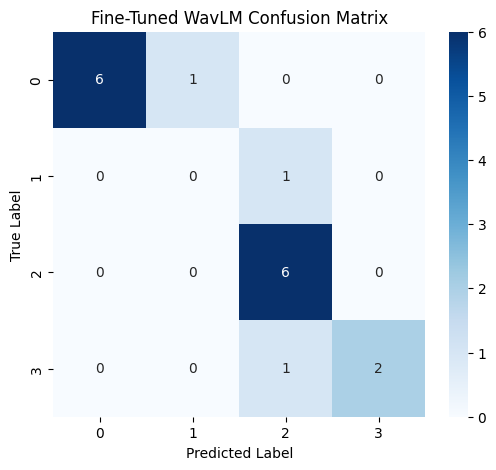

In [50]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3],
    yticklabels=[0, 1, 2, 3]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fine-Tuned WavLM Confusion Matrix")

plt.show()

In [51]:
report_ft = classification_report(
    y_true_ft,
    y_pred_ft,
    labels=[0, 1, 2, 3],
    output_dict=True,
    zero_division=0
)

per_class_f1_ft = [
    report_ft[str(i)]["f1-score"]
    for i in range(4)
]

for i, score in enumerate(per_class_f1_ft):
    print(
        f"Label {i} F1: {score:.4f}"
    )

Label 0 F1: 0.9231
Label 1 F1: 0.0000
Label 2 F1: 0.8571
Label 3 F1: 0.8000


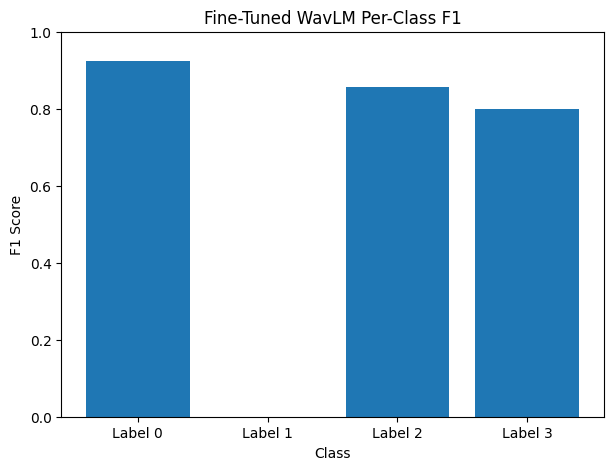

In [52]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Label 0", "Label 1", "Label 2", "Label 3"],
    per_class_f1_ft
)

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Fine-Tuned WavLM Per-Class F1")

plt.ylim(0, 1)

plt.show()

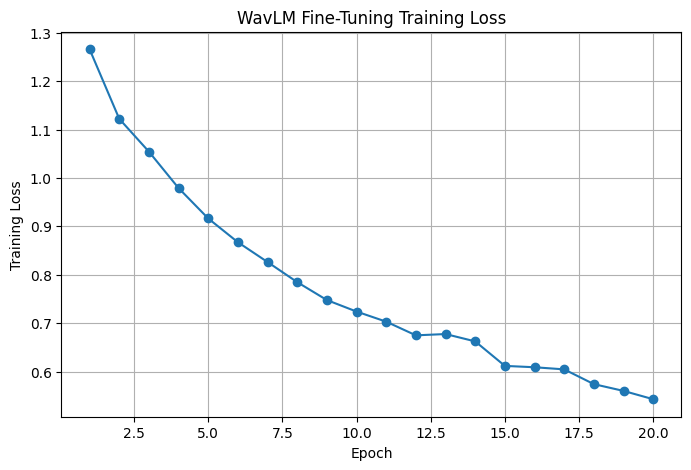

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    ft_history_df["epoch"],
    ft_history_df["train_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("WavLM Fine-Tuning Training Loss")

plt.grid(True)

plt.show()

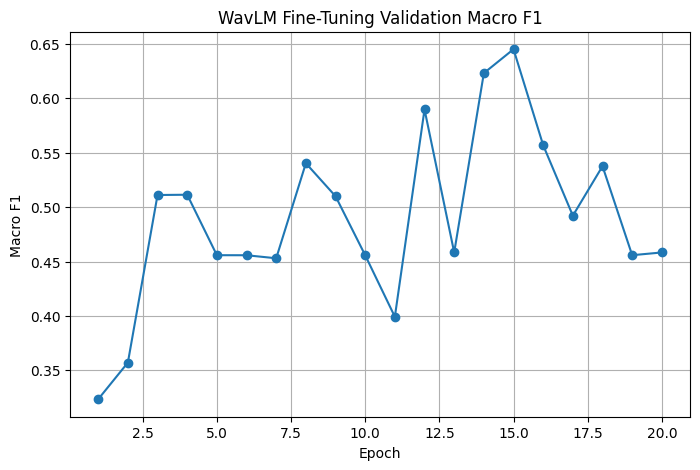

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    ft_history_df["epoch"],
    ft_history_df["val_macro_f1"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("WavLM Fine-Tuning Validation Macro F1")

plt.grid(True)

plt.show()

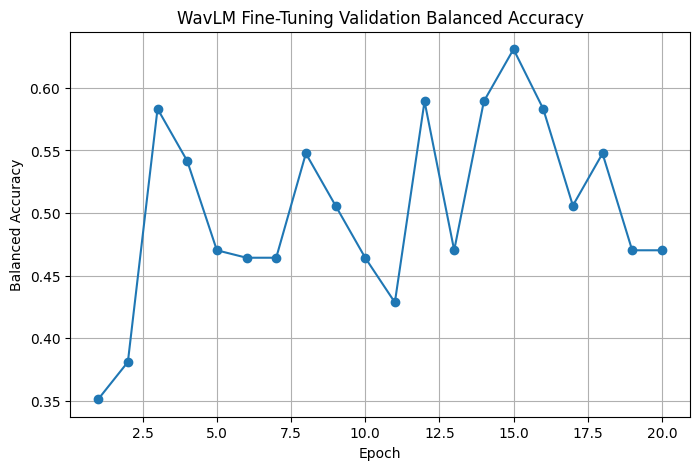

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(
    ft_history_df["epoch"],
    ft_history_df["val_balanced_accuracy"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title(
    "WavLM Fine-Tuning Validation Balanced Accuracy"
)

plt.grid(True)

plt.show()

In [56]:
final_comparison = pd.DataFrame({

    "Model": [
        "MFCC + SVM",
        "Log-Mel + CNN",
        "Frozen WavLM + MLP",
        "Fine-Tuned WavLM"
    ],

    "Macro F1": [
        0.3529,
        0.4762,
        frozen_f1,
        ft_f1
    ],

    "Balanced Accuracy": [
        0.3518,
        0.4286,
        frozen_balanced_acc,
        ft_balanced_acc
    ],

    "Accuracy": [
        0.5056,
        np.nan,
        frozen_accuracy,
        ft_accuracy
    ]
})

final_comparison


,Model,Macro F1,Balanced Accuracy,Accuracy
0,MFCC + SVM,0.352900,0.351800,0.505600
1,Log-Mel + CNN,0.476200,0.428600,NaN
2,Frozen WavLM + MLP,0.510417,0.541667,0.705882
3,Fine-Tuned WavLM,0.645055,0.630952,0.823529


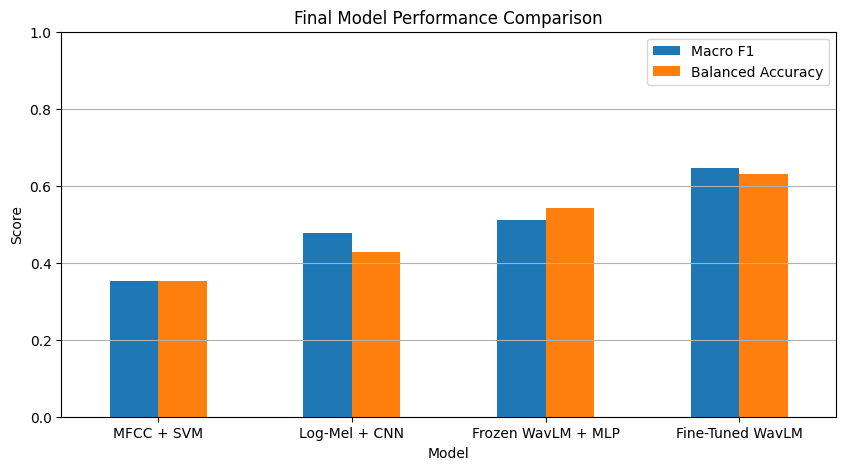

In [57]:
final_comparison.set_index(
    "Model"
)[
    ["Macro F1", "Balanced Accuracy"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Final Model Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [58]:
best_model = final_comparison.loc[
    final_comparison["Macro F1"].idxmax()
]

print("Best model based on Macro F1:")
print()

print(
    "Model:",
    best_model["Model"]
)

print(
    "Macro F1:",
    f"{best_model['Macro F1']:.4f}"
)

print(
    "Balanced Accuracy:",
    f"{best_model['Balanced Accuracy']:.4f}"
)

Best model based on Macro F1:

Model: Fine-Tuned WavLM
Macro F1: 0.6451
Balanced Accuracy: 0.6310


In [59]:
TEST_CSV_PATH = os.path.join(
    DATASET_PATH,
    "Test.csv"
)

test_df = pd.read_csv(TEST_CSV_PATH)

test_df["audio_path"] = test_df["File_name"].apply(
    lambda x: os.path.join(TEST_AUDIO_PATH, x)
)

print("Test shape:", test_df.shape)
print(test_df.head())

Test shape: (24, 6)
  Participant File_name  Gender  Age  Remark  \
0        S018  S018.mp3    Male   30     NaN   
1        S068  S068.mp3  Female   32     NaN   
2        S106  S106.mp3  Female   34     NaN   
3        S013  S013.mp3    Male   16     NaN   
4        S070  S070.mp3  Female   17     NaN   

                                          audio_path  
0  /content/drive/MyDrive/bio-cas-2024-depression...  
1  /content/drive/MyDrive/bio-cas-2024-depression...  
2  /content/drive/MyDrive/bio-cas-2024-depression...  
3  /content/drive/MyDrive/bio-cas-2024-depression...  
4  /content/drive/MyDrive/bio-cas-2024-depression...  


In [60]:
print(
    test_df[
        ["Participant", "File_name"]
    ].head()
)

  Participant File_name
0        S018  S018.mp3
1        S068  S068.mp3
2        S106  S106.mp3
3        S013  S013.mp3
4        S070  S070.mp3


In [61]:
test_df["file_exists"] = test_df[
    "audio_path"
].apply(os.path.isfile)

print(
    "Existing audio files:",
    test_df["file_exists"].sum()
)

print(
    "Missing audio files:",
    (~test_df["file_exists"]).sum()
)

Existing audio files: 24
Missing audio files: 0


In [65]:
def predict_test_wavlm(
    dataframe,
    model,
    feature_extractor,
    device,
    sr=16000,
    segment_duration=5
):

    model.eval()

    segment_samples = sr * segment_duration

    participant_predictions = {}

    for _, row in dataframe.iterrows():

        participant = row["Participant"]
        audio_path = row["audio_path"]

        audio, _ = librosa.load(
            audio_path,
            sr=sr,
            mono=True
        )

        # Safety check for empty audio
        if len(audio) == 0:
            print(
                f"Skipping empty audio: {participant}"
            )
            continue

        segment_probs = []

        # --------------------------------
        # Case 1: Audio >= 5 seconds
        # --------------------------------

        num_segments = (
            len(audio) // segment_samples
        )

        for segment_idx in range(num_segments):

            start = (
                segment_idx *
                segment_samples
            )

            end = (
                start +
                segment_samples
            )

            segment = audio[start:end]

            inputs = feature_extractor(
                segment,
                sampling_rate=sr,
                return_tensors="pt"
            )

            input_values = (
                inputs.input_values
                .to(device)
            )

            with torch.no_grad():

                outputs = model(
                    input_values
                )

                probs = torch.softmax(
                    outputs,
                    dim=1
                )

            segment_probs.append(
                probs.squeeze(0)
                .cpu()
                .numpy()
            )

        # --------------------------------
        # Case 2: Audio < 5 seconds
        # Pad to exactly 5 seconds
        # --------------------------------

        if len(segment_probs) == 0:

            padded_audio = np.zeros(
                segment_samples,
                dtype=np.float32
            )

            padded_audio[:len(audio)] = audio

            inputs = feature_extractor(
                padded_audio,
                sampling_rate=sr,
                return_tensors="pt"
            )

            input_values = (
                inputs.input_values
                .to(device)
            )

            with torch.no_grad():

                outputs = model(
                    input_values
                )

                probs = torch.softmax(
                    outputs,
                    dim=1
                )

            segment_probs.append(
                probs.squeeze(0)
                .cpu()
                .numpy()
            )

        # --------------------------------
        # Participant-level aggregation
        # --------------------------------

        avg_prob = np.mean(
            segment_probs,
            axis=0
        )

        prediction = int(
            np.argmax(avg_prob)
        )

        participant_predictions[
            participant
        ] = {
            "prediction": prediction,
            "probabilities": avg_prob,
            "num_segments": len(segment_probs)
        }

        print(
            f"{participant} -> "
            f"Label {prediction} "
            f"({len(segment_probs)} segments)"
        )

    return participant_predictions

In [66]:
fine_tune_model.load_state_dict(
    torch.load(
        BEST_FT_PATH,
        map_location=device
    )
)

fine_tune_model.eval()

print(
    "Best fine-tuned WavLM checkpoint loaded."
)

Best fine-tuned WavLM checkpoint loaded.


In [67]:
start_time = time.time()

test_predictions = predict_test_wavlm(
    test_df,
    fine_tune_model,
    feature_extractor,
    device
)

elapsed = time.time() - start_time

print(
    f"\nTest inference completed in "
    f"{elapsed/60:.2f} minutes"
)

print(
    "Number of predictions:",
    len(test_predictions)
)

S018 -> Label 2 (1 segments)


/tmp/ipykernel_697/858297240.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


S068 -> Label 2 (66 segments)


/tmp/ipykernel_697/858297240.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


S106 -> Label 1 (22 segments)
S013 -> Label 2 (107 segments)


...

S109 -> Label 0 (17 segments)
S076 -> Label 2 (77 segments)
S006 -> Label 2 (142 segments)
S038 -> Label 2 (28 segments)
S086 -> Label 0 (27 segments)
S010 -> Label 2 (119 segments)


/tmp/ipykernel_697/858297240.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


S025 -> Label 2 (96 segments)


/tmp/ipykernel_697/858297240.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


S079 -> Label 1 (83 segments)
S067 -> Label 2 (102 segments)
S095 -> Label 0 (84 segments)
S039 -> Label 2 (33 segments)
S077 -> Label 2 (141 segments)
S041 -> Label 2 (218 segments)
S048 -> Label 2 (26 segments)

Test inference completed in 2.16 minutes
Number of predictions: 24


In [68]:
prediction_rows = []

for participant, result in test_predictions.items():

    prediction_rows.append({
        "Participant": participant,
        "Prediction": result["prediction"],
        "Num_Segments": result["num_segments"]
    })

predictions_df = pd.DataFrame(
    prediction_rows
)

predictions_df.head()

,Participant,Prediction,Num_Segments
0,S018,2,1
1,S068,2,66
2,S106,1,22
3,S013,2,107
4,S070,2,83


In [69]:
print(
    predictions_df[
        "Prediction"
    ].value_counts().sort_index()
)

Prediction
0     5
1     2
2    16
3     1
Name: count, dtype: int64


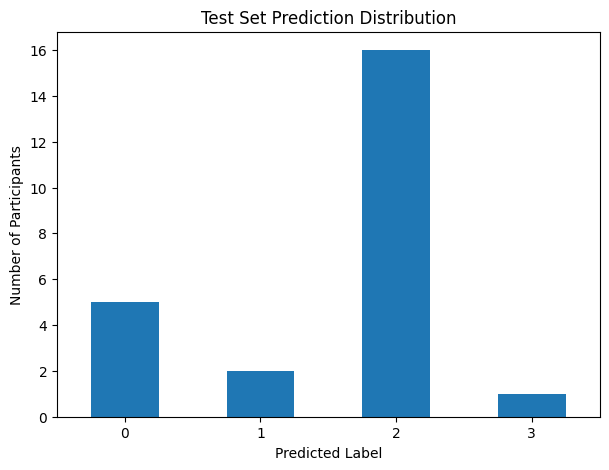

In [70]:
plt.figure(figsize=(7, 5))

predictions_df[
    "Prediction"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Predicted Label")
plt.ylabel("Number of Participants")
plt.title(
    "Test Set Prediction Distribution"
)

plt.xticks(rotation=0)

plt.show()

In [71]:
predictions_df

,Participant,Prediction,Num_Segments
0,S018,2,1
1,S068,2,66
2,S106,1,22
3,S013,2,107
4,S070,2,83
5,S093,0,15
6,S001,3,53
7,S103,2,13
8,S049,2,83
9,S094,0,15


In [72]:
sample_submission_path = os.path.join(
    DATASET_PATH,
    "sample_submission.csv"
)

sample_submission = pd.read_csv(
    sample_submission_path
)

print(
    "Sample submission shape:",
    sample_submission.shape
)

print(
    "Sample submission columns:",
    sample_submission.columns.tolist()
)

sample_submission.head()

Sample submission shape: (24, 2)
Sample submission columns: ['Participant', 'Label']


,Participant,Label
0,S018,"0, 1"
1,S068,NaN
2,S106,NaN
3,S013,NaN
4,S070,NaN


In [73]:
# Create submission file from test predictions

submission = sample_submission.copy()

# Map participant -> predicted label
submission["Label"] = submission["Participant"].map(
    lambda participant: test_predictions[participant]["prediction"]
)

# Check for missing predictions
print("Missing predictions:", submission["Label"].isna().sum())

# Display final submission
display(submission)

Missing predictions: 0


,Participant,Label
0,S018,2
1,S068,2
2,S106,1
3,S013,2
4,S070,2
5,S093,0
6,S001,3
7,S103,2
8,S049,2
9,S094,0


In [74]:
submission_path = os.path.join(DATASET_PATH, "submission.csv")

submission.to_csv(submission_path, index=False)

print("Submission saved at:")
print(submission_path)

Submission saved at:
/content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge/submission.csv


###   Best model based on Macro F1:

Model: Fine-Tuned WavLM
Macro F1: 0.6451
Balanced Accuracy: 0.6310